In [1]:
import os
import numpy as np
import pandas as pd
from tensorflow import keras
import autokeras as ak
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure you're using Keras 3 and AutoKeras 1.0.18+
print("Keras version:", keras.__version__)
print("AutoKeras version:", ak.__version__)

# Set seeds for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

2025-03-28 18:03:23.773158: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-28 18:03:26.036779: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743203006.851579     119 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743203007.077549     119 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-28 18:03:29.245755: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Keras version: 3.8.0
AutoKeras version: 2.0.0


In [8]:
# Load data
df_hemo = pd.read_csv(os.path.expanduser('~/merged_hemorrhage_embeddings.csv'))
df_control = pd.read_csv(os.path.expanduser('~/merged_control_embeddings.csv'))
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert embeddings
df['embedding'] = df['embedding'].apply(eval)
X = np.array(df['embedding'].tolist(), dtype=np.float32)

# Multi-label target preparation
target_columns = ['any', 'epidural', 'intraparenchymal', 
                 'intraventricular', 'subarachnoid', 'subdural']
y = df[target_columns].values.astype(np.float32)

# Split data with stratification on 'any' column
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y[:,0],  # Stratify by 'any' hemorrhage
    random_state=42
)

In [9]:
def weighted_binary_ce(y_true, y_pred):
    """Custom loss with 2x weight for 'any' hemorrhage (first column)"""
    # Calculate base binary crossentropy
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    
    # Create weight matrix with 2x weight for first column
    weights = tf.ones_like(y_true)
    weights = tf.tensor_scatter_nd_update(
        weights,
        indices=tf.constant([[i, 0] for i in range(tf.shape(y_true)[0])]),
        updates=tf.constant([2.0]*tf.shape(y_true)[0])
    )
    
    return tf.reduce_mean(bce * weights)

In [19]:
# Define the AutoKeras model
input_node = ak.Input()
output_node = ak.Normalization()(input_node)
output_node = ak.DenseBlock()(output_node)
output_node = ak.ClassificationHead()(output_node)

auto_model = ak.AutoModel(
    inputs=input_node,
    outputs=output_node,
    overwrite=True,
    max_trials=15  # Adjust based on computational resources
)

In [20]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5', 
    monitor='val_loss', 
    save_best_only=True
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [21]:
# Train the model with callbacks
auto_model.fit(
    X_train, y_train,
    epochs=100,  # Set a high number; early stopping will halt training when appropriate
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks
)

Trial 15 Complete [00h 00m 10s]
val_loss: 2.1720752716064453

Best val_loss So Far: 1.997951626777649
Total elapsed time: 00h 02m 43s
Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2168 - loss: 2.4206 - learning_rate: 0.0010
Epoch 2/100
 70/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4822 - loss: 2.4860 

/home/bahram/.local/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/home/bahram/.local/lib/python3.10/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
/home/bahram/.local/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)
/home/bahram/.local/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.g

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4956 - loss: 2.5685 - learning_rate: 0.0010
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4817 - loss: 2.8751 - learning_rate: 0.0010
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4619 - loss: 3.2281 - learning_rate: 0.0010
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4573 - loss: 3.5917 - learning_rate: 0.0010
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4503 - loss: 3.9610 - learning_rate: 0.0010
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4494 - loss: 4.3163 - learning_rate: 0.0010
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4358 - loss: 4.7424 - learning_rate: 0.0010
Epoch 9/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4281 - loss: 5.0406 - learning_rate: 0.0010
Epoch 10/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4263 - loss: 5.4648 - learning_rate: 0.0010
Epoch 11/100

/home/bahram/.local/lib/python3.10/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 1408))
  warnings.warn(msg)


 83/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

2025-03-25 20:21:07.977566: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_42_0', 8 bytes spill stores, 8 bytes spill loads

2025-03-25 20:21:08.206175: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_42_0', 4 bytes spill stores, 4 bytes spill loads

2025-03-25 20:21:08.384469: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_42', 108 bytes spill stores, 108 bytes spill loads



101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
any AUC: 0.8616
epidural AUC: 0.5934
intraparenchymal AUC: 0.7572
intraventricular AUC: 0.7243
subarachnoid AUC: 0.7259
subdural AUC: 0.7111


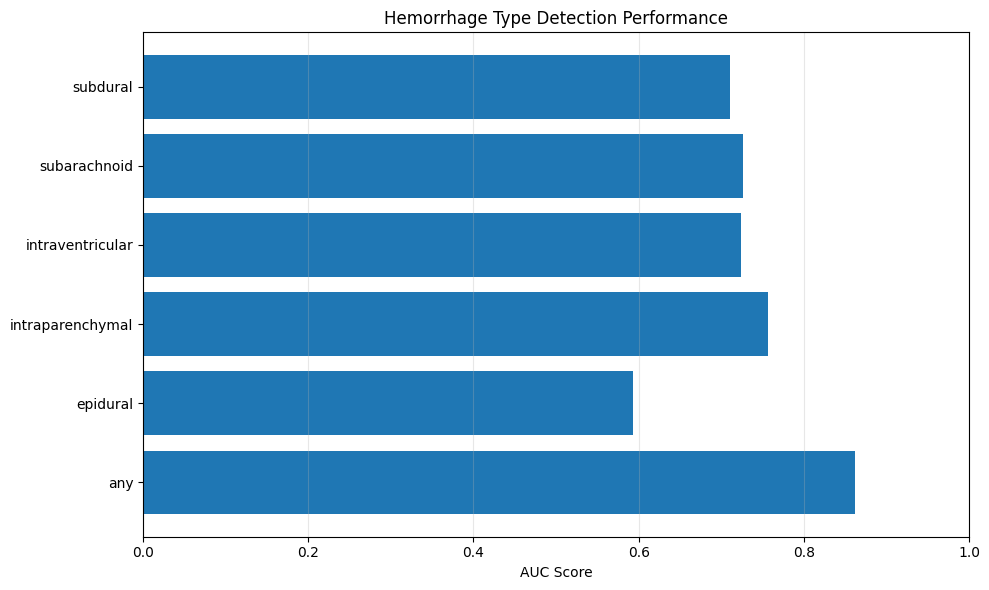

In [22]:
best_model = model.export_model()
y_pred = best_model.predict(X_test).astype(np.float32)

# Calculate AUC scores
auc_scores = {}
for i, col in enumerate(target_columns):
    auc = tf.keras.metrics.AUC()(y_test[:,i], y_pred[:,i])
    auc_scores[col] = auc.numpy()
    print(f"{col} AUC: {auc:.4f}")

# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(list(auc_scores.keys()), list(auc_scores.values()))
plt.title('Hemorrhage Type Detection Performance')
plt.xlabel('AUC Score')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()